# FM Tetris Rotator (with Correction UNet)

Minimal notebook for a quick MPS sanity-check run. Trains a small flow-matching rotator
and a lightweight UNet corrector that refines the final rotated image.

In [11]:
%cd /Users/masha/Documents/visual-reasoning

/Users/masha/Documents/visual-reasoning


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import numpy as np
import matplotlib.pyplot as plt
import timm
import kornia.geometry.transform as K
import cv2
import random

In [13]:
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Fast sanity-check config (few minutes on MPS)
BATCH_SIZE = 32
IMG_SIZE = 64
EPOCHS = 100
TRAIN_SAMPLES = 16000
TEST_SAMPLES = 4000
DT = 0.1

FLOW_DIM = 24   # smaller for fast iteration
CORR_BASE = 16  # corrector width
CORR_WEIGHT = 0.5

print("Device:", DEVICE)

Device: mps


In [14]:
CHIRAL_SHAPES = {
    'L': [(0, -1), (0, 0), (0, 1), (1, 1)],
    'J': [(0, -1), (0, 0), (0, 1), (-1, 1)],
    'S': [(0, 0), (1, 0), (0, 1), (-1, 1)],
    'Z': [(0, 0), (-1, 0), (0, 1), (1, 1)],
    'F': [(0, 0), (0, -1), (1, -1), (-1, 0), (0, 1)],
    'P': [(0, 0), (0, -1), (1, -1), (1, 0), (0, 1)],
}

def draw_shape(name, size):
    img = np.zeros((size, size), dtype=np.uint8)
    center = size // 2
    block_size = size // 8
    for dx, dy in CHIRAL_SHAPES[name]:
        x = center + (dx * block_size) - (block_size // 2)
        y = center + (dy * block_size) - (block_size // 2)
        cv2.rectangle(img, (x, y), (x + block_size, y + block_size), 255, -1)
    return img

# Precompute DINO embeddings per shape
print("Building shape cache...")
dino = timm.create_model("vit_small_patch16_dinov3", pretrained=True).to(DEVICE).eval()

SHAPE_CACHE = {}
with torch.no_grad():
    for name in CHIRAL_SHAPES.keys():
        big_img = draw_shape(name, 224)
        t_big = torch.tensor(big_img).float().unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1).to(DEVICE) / 255.0
        t_big = transforms.Normalize([0.485], [0.229])(t_big)
        emb = dino.forward_features(t_big)[:, 0, :]

        small_img = draw_shape(name, IMG_SIZE)
        t_small = torch.tensor(small_img).float().unsqueeze(0) / 255.0
        t_small = (t_small - 0.5) / 0.5

        SHAPE_CACHE[name] = {"img": t_small, "emb": emb.cpu()}

# Free DINO to save memory
if DEVICE.type == "mps":
    torch.mps.empty_cache()
del dino

Building shape cache...


In [15]:
class FastTetrisDataset(Dataset):
    def __init__(self, n_samples=2000):
        self.keys = list(CHIRAL_SHAPES.keys())
        self.n = n_samples
    def __len__(self):
        return self.n
    def __getitem__(self, idx):
        key = random.choice(self.keys)
        data = SHAPE_CACHE[key]
        return data["img"], data["emb"]  # (1, 64, 64), (1, 384)

train_loader = DataLoader(FastTetrisDataset(TRAIN_SAMPLES), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(FastTetrisDataset(TEST_SAMPLES), batch_size=BATCH_SIZE)

In [16]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.net(x)

class FastRotator(nn.Module):
    def __init__(self, backbone_dim=384, flow_dim=FLOW_DIM):
        super().__init__()
        self.time_mlp = nn.Sequential(nn.Linear(1, flow_dim*4), nn.GELU(), nn.Linear(flow_dim*4, flow_dim*4))
        self.angle_mlp = nn.Sequential(nn.Linear(1, flow_dim*4), nn.GELU(), nn.Linear(flow_dim*4, flow_dim*4))
        self.cond_proj = nn.Linear(backbone_dim, flow_dim*4)

        self.inc = DoubleConv(1, flow_dim)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim, flow_dim*2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(flow_dim*2, flow_dim*4))

        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = DoubleConv(flow_dim*6, flow_dim*2)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv2 = DoubleConv(flow_dim*3, flow_dim)

        self.outc = nn.Conv2d(flow_dim, 1, kernel_size=1)

    def forward(self, x_t, t, dino_emb, target_angle_deg):
        t_emb = self.time_mlp(t)
        d_emb = self.cond_proj(dino_emb)
        a_emb = self.angle_mlp(target_angle_deg / 360.0)
        global_cond = (t_emb + d_emb + a_emb).unsqueeze(-1).unsqueeze(-1)

        x1 = self.inc(x_t)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x3 = x3 + global_cond

        x = self.conv1(torch.cat([self.up1(x3), x2], dim=1))
        x = self.conv2(torch.cat([self.up2(x), x1], dim=1))
        return self.outc(x)

class CorrectorUNet(nn.Module):
    def __init__(self, base_ch=CORR_BASE):
        super().__init__()
        self.inc = DoubleConv(1, base_ch)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base_ch, base_ch*2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base_ch*2, base_ch*4))
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv1 = DoubleConv(base_ch*6, base_ch*2)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv2 = DoubleConv(base_ch*3, base_ch)
        self.outc = nn.Conv2d(base_ch, 1, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x = self.conv1(torch.cat([self.up1(x3), x2], dim=1))
        x = self.conv2(torch.cat([self.up2(x), x1], dim=1))
        return self.outc(x)

rotator = FastRotator().to(DEVICE)
corrector = CorrectorUNet().to(DEVICE)
optimizer = optim.AdamW(list(rotator.parameters()) + list(corrector.parameters()), lr=2e-4)

Epoch 5: 0.71116
Epoch 10: 0.35084
Epoch 15: 0.24085
Epoch 20: 0.18355
Epoch 25: 0.16547
Epoch 30: 0.14102
Epoch 35: 0.12067
Epoch 40: 0.11368
Epoch 45: 0.10291
Epoch 50: 0.09039
Epoch 55: 0.08735
Epoch 60: 0.07984
Epoch 65: 0.07764
Epoch 70: 0.07051
Epoch 75: 0.06520
Epoch 80: 0.06642
Epoch 85: 0.06764
Epoch 90: 0.06112
Epoch 95: 0.05692
Epoch 100: 0.05456


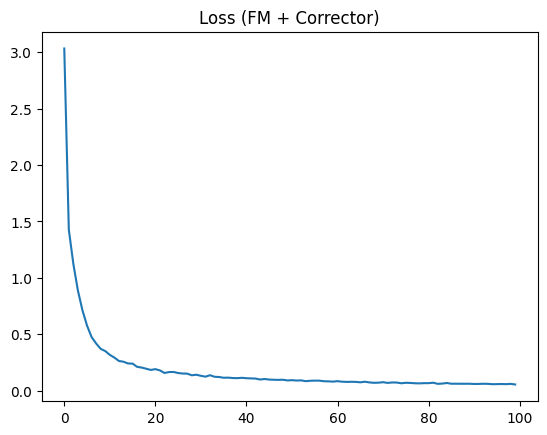

In [17]:
train_losses = []

for epoch in range(EPOCHS):
    rotator.train()
    corrector.train()
    epoch_loss = 0.0

    for base_img, base_emb in train_loader:
        base_img = base_img.to(DEVICE)
        base_emb = base_emb.to(DEVICE).squeeze(1)
        B = base_img.shape[0]

        ang_start = torch.rand(B, device=DEVICE) * 360
        ang_delta = torch.rand(B, device=DEVICE) * 360 - 180
        t = torch.rand(B, 1, device=DEVICE)

        ang_t = ang_start + (t.squeeze() * ang_delta)
        x_t = K.rotate(base_img, ang_t)

        ang_next = ang_t + (DT * ang_delta)
        x_next = K.rotate(base_img, ang_next)

        target_v = (x_next - x_t) / DT
        pred_v = rotator(x_t, t, base_emb, ang_delta.view(B, 1))

        x_pred = x_t + pred_v * DT
        corr = corrector(x_pred)
        x_corr = (x_pred + corr).clamp(-1.0, 1.0)

        loss_v = F.mse_loss(pred_v, target_v)
        loss_corr = F.mse_loss(x_corr, x_next)
        loss = loss_v + CORR_WEIGHT * loss_corr

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg = epoch_loss / len(train_loader)
    train_losses.append(avg)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}: {avg:.5f}")

plt.plot(train_losses)
plt.title("Loss (FM + Corrector)")
plt.show()

In [18]:
@torch.no_grad()
def apply_rotation(model, corrector, base_img, base_emb, angle_deg, steps=10):
    model.eval()
    corrector.eval()
    dt = 1.0 / steps
    curr = base_img.clone()
    B = base_img.shape[0]

    target_ang = torch.full((B, 1), float(angle_deg), device=DEVICE)
    for i in range(steps):
        t = torch.full((B, 1), i / steps, device=DEVICE)
        v = model(curr, t, base_emb, target_ang)
        curr = curr + v * dt

    corr = corrector(curr)
    curr = (curr + corr).clamp(-1.0, 1.0)
    return curr

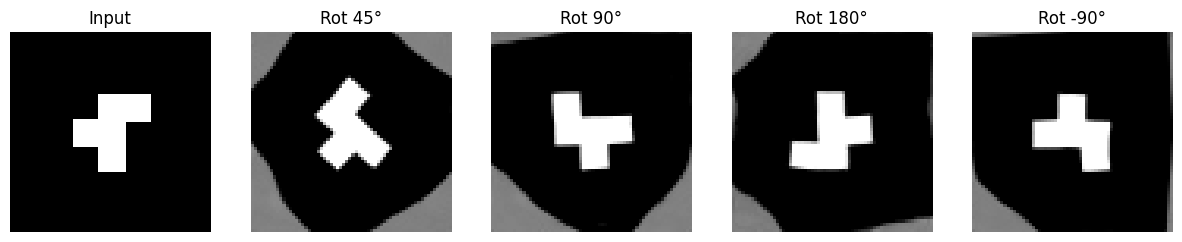

In [19]:
# Visualize
rotator.eval()
corrector.eval()

data = next(iter(test_loader))
sample_img = data[0][0:1].to(DEVICE)
sample_emb = data[1][0:1].to(DEVICE).squeeze(1)

angles = [45, 90, 180, -90]
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

axes[0].imshow(sample_img[0,0].cpu(), cmap='gray')
axes[0].set_title("Input")
axes[0].axis('off')

for i, ang in enumerate(angles):
    out = apply_rotation(rotator, corrector, sample_img, sample_emb, float(ang))
    axes[i+1].imshow(out[0,0].cpu(), cmap='gray')
    axes[i+1].set_title(f"Rot {ang}°")
    axes[i+1].axis('off')

plt.show()

In [21]:
rotator_path = "models/rotator_fm_tetris_with_corrector.pth"
corrector_path = "models/rotator_fm_tetris_corrector.pth"

torch.save(rotator.state_dict(), rotator_path)
torch.save(corrector.state_dict(), corrector_path)

rotator_path, corrector_path

('models/rotator_fm_tetris_with_corrector.pth',
 'models/rotator_fm_tetris_corrector.pth')